In [3]:
%run ./unified_prediction_engine.ipynb

Heart Disease Prediction: 0
Diabetes Prediction: 1
Cancer Prediction: 0


In [4]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [5]:
heart_df = pd.read_csv("../data/raw/heart.csv")
diabetes_df = pd.read_csv("../data/raw/diabetes.csv")
cancer_df = pd.read_csv("../data/raw/breast_cancer.csv")

heart_model = joblib.load("../models/trained_models/heart_RandomForest.pkl")
diabetes_model = joblib.load("../models/trained_models/diabetes_RandomForest.pkl")
cancer_model = joblib.load("../models/trained_models/cancer_RandomForest.pkl")


Feature Names


In [6]:
#Heart Features
heart_features = [
    "age", "sex", "chest_pain", "blood_pressure", "cholesterol",
    "fasting_blood_sugar", "rest_ecg", "max_heart_rate",
    "exercise_angina", "oldpeak", "slope", "ca", "thal"
]

In [7]:
#Diabetes Features
diabetes_features = [
    "pregnancies", "glucose", "blood_pressure", "skin_thickness",
    "insulin", "bmi", "diabetes_pedigree_function", "age"
]

In [8]:
#Breast Cancer Features
cancer_features = [
    "mean_radius", "mean_texture", "mean_perimeter", "mean_area",
    "mean_smoothness", "mean_compactness"
]

Model Based Feature Importance

In [9]:
#Heart Importance
def show_heart_importance():

    importances = heart_model.feature_importances_

    data = pd.DataFrame({
        "Feature": heart_features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\n❤️ Heart Disease Feature Importance:\n")
    print(data)

    data.plot(kind="bar", x="Feature", y="Importance", legend=False)
    plt.title("Heart Disease Feature Importance")
    plt.show()

In [10]:
#Diabetes Importance
def show_diabetes_importance():

    importances = diabetes_model.feature_importances_

    data = pd.DataFrame({
        "Feature": diabetes_features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\n🩸 Diabetes Feature Importance:\n")
    print(data)

    data.plot(kind="bar", x="Feature", y="Importance", legend=False)
    plt.title("Diabetes Feature Importance")
    plt.show()

In [11]:
# Cancer Importance
def show_cancer_importance():

    importances = cancer_model.feature_importances_[:6]

    data = pd.DataFrame({
        "Feature": cancer_features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\n🎗 Cancer Feature Importance:\n")
    print(data)

    data.plot(kind="bar", x="Feature", y="Importance", legend=False)
    plt.title("Cancer Feature Importance")
    plt.show()

User Friendly Result System

In [12]:
#Heart Explanation
def explain_heart_prediction(result):

    if result == 1:
        print("\n⚠ HIGH RISK OF HEART DISEASE")
        print("Possible reasons:")
        print("- Abnormal cholesterol levels")
        print("- High blood pressure")
        print("- Chest pain indicators")
        print("- Reduced heart performance")

        print("\n⚠ Recommendation:")
        print("Consult a cardiologist immediately")

    else:
        print("\n✅ LOW RISK OF HEART DISEASE")
        print("Maintain healthy lifestyle")

In [13]:
#Diabetes Explanation
def explain_diabetes_prediction(result):

    if result == 1:
        print("\n⚠ HIGH RISK OF DIABETES")
        print("Possible reasons:")
        print("- High glucose level")
        print("- BMI imbalance")
        print("- Insulin issues")

        print("\n⚠ Recommendation:")
        print("Consult an endocrinologist")

    else:
        print("\n✅ LOW RISK OF DIABETES")

In [14]:
#Cancer Explanation
def explain_cancer_prediction(result):

    if result == 1:
        print("\n⚠ HIGH RISK OF CANCER DETECTED")
        print("Important indicators detected in tissue pattern")

        print("\n⚠ Recommendation:")
        print("Immediate medical diagnosis required")

    else:
        print("\n✅ LOW RISK OF CANCER")


Upgraded Prediction System for each

In [15]:
#For Heart Disease
def heart_system(data):

    prediction = heart_model.predict(np.array(data).reshape(1, -1))[0]

    explain_heart_prediction(prediction)

    return prediction

In [16]:
#For Diabetes
def diabetes_system(data):

    prediction = diabetes_model.predict(np.array(data).reshape(1, -1))[0]

    explain_diabetes_prediction(prediction)

    return prediction

In [17]:
#For Breast Cancer
def cancer_system(data):

    prediction = cancer_model.predict(np.array(data).reshape(1, -1))[0]

    explain_cancer_prediction(prediction)

    return prediction

Function to run explanation system

In [18]:
def run_explainer_system():

    print("\n🏥 EXPLAINABLE MEDICAL AI SYSTEM")

    print("1. Heart Disease")
    print("2. Diabetes")
    print("3. Cancer")

    choice = input("\nSelect Disease: ")


    # HEART DISEASE

    if choice == "1":

        # TAKE USER INPUT
        data = get_heart_input()

        # PREDICT
        prediction = heart_model.predict(
            np.array(data).reshape(1, -1)
        )[0]

        # SHOW EXPLANATION
        explain_heart_prediction(prediction)

        # SHOW FEATURE IMPORTANCE
        show_heart_importance()


    # DIABETES

    elif choice == "2":

        data = get_diabetes_input()

        prediction = diabetes_model.predict(
            np.array(data).reshape(1, -1)
        )[0]

        explain_diabetes_prediction(prediction)

        show_diabetes_importance()


    # CANCER

    elif choice == "3":

        data = get_cancer_input()

        prediction = cancer_model.predict(
            np.array(data).reshape(1, -1)
        )[0]

        explain_cancer_prediction(prediction)

        show_cancer_importance()


    else:

        print("\nInvalid Choice")


🏥 EXPLAINABLE MEDICAL AI SYSTEM
1. Heart Disease
2. Diabetes
3. Cancer

🩸 DIABETES RISK PREDICTION
⚠ Enter values carefully (numbers only where required)


⚠ HIGH RISK OF DIABETES
Possible reasons:
- High glucose level
- BMI imbalance
- Insulin issues

⚠ Recommendation:
Consult an endocrinologist

🩸 Diabetes Feature Importance:

                      Feature  Importance
1                     glucose    0.265137
5                         bmi    0.162058
7                         age    0.136899
6  diabetes_pedigree_function    0.122115
4                     insulin    0.088740
2              blood_pressure    0.081944
3              skin_thickness    0.072449
0                 pregnancies    0.070658


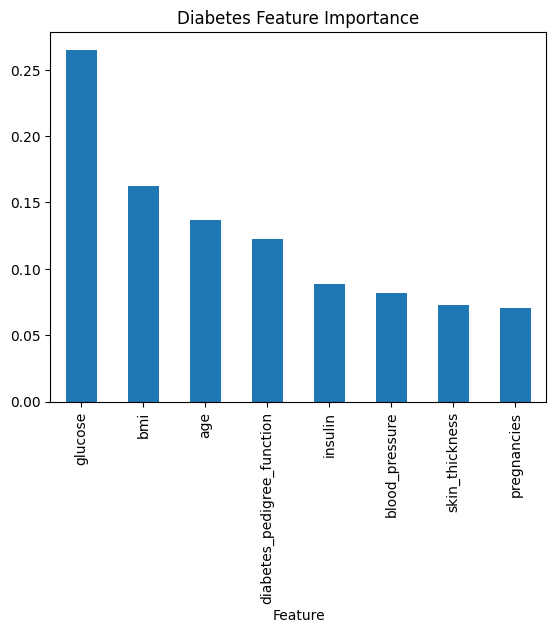

In [19]:
run_explainer_system()